In [ ]:
source_dir = "/content/drive/MyDrive/Datasets 4"


In [ ]:
source_dir = "/content/drive/MyDrive/Datasets 4/lfw-deepfunneled"
target_dir = "/content/drive/MyDrive/Datasets 4/selected_faces"
min_images = 4

In [ ]:
import os
import shutil

source_dir = "/content/drive/MyDrive/Datasets 4/lfw-deepfunneled"
target_dir = "/content/drive/MyDrive/Datasets 4/selected_faces"
min_images = 4

# Before trying to list contents of source_dir, let's check its existence
if not os.path.exists(source_dir):
    print(f"Error: Source directory '{source_dir}' not found.")
    print("Please verify the path and ensure Google Drive is mounted correctly.")
    print("Contents of '/content/drive/MyDrive/Datasets 4':")
    try:
        print(os.listdir("/content/drive/MyDrive/Datasets 4"))
    except FileNotFoundError:
        print("The parent directory '/content/drive/MyDrive/Datasets 4' also not found.")
    except Exception as e:
        print(f"An error occurred while listing parent directory: {e}")
else:
    os.makedirs(target_dir, exist_ok=True)

    kept_people = 0
    removed_people = 0

    for person_name in os.listdir(source_dir):
        person_path = os.path.join(source_dir, person_name)

        if not os.path.isdir(person_path):
            continue

        images = [
            f for f in os.listdir(person_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        if len(images) >= min_images:
            target_person_path = os.path.join(target_dir, person_name)
            shutil.copytree(person_path, target_person_path, dirs_exist_ok=True)
            kept_people += 1
        else:
            removed_people += 1

    print(f"People kept: {kept_people}")
    print(f"People removed: {removed_people}")
    print(f"Filtered dataset saved in: {target_dir}")


Error: Source directory '/content/drive/MyDrive/Datasets 4/lfw-deepfunneled' not found.
Please verify the path and ensure Google Drive is mounted correctly.
Contents of '/content/drive/MyDrive/Datasets 4':
['selected_faces', 'Split datasets ', 'split_dataset', 'y_train_labels.npy', 'label_encoder.pkl', 'X_train_embeddings.npy', 'facenet_svm_model.pkl', 'top_faces']


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Datasets 4"))

['selected_faces', 'Split datasets ', 'split_dataset', 'y_train_labels.npy', 'label_encoder.pkl', 'X_train_embeddings.npy', 'facenet_svm_model.pkl', 'top_faces']


In [ ]:
print(os.listdir("/content/drive/MyDrive/Datasets 4/")[:10])

['selected_faces', 'Split datasets ', 'split_dataset', 'y_train_labels.npy', 'label_encoder.pkl', 'X_train_embeddings.npy', 'facenet_svm_model.pkl', 'top_faces']


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/Datasets 4/selected_faces"))

True


In [ ]:
!zip -r "/content/selected_faces.zip" "/content/drive/MyDrive/Datasets 4/selected_faces"

Streaming output truncated to the last 5000 lines.
  adding: content/drive/MyDrive/Datasets 4/selected_faces/Donald_Rumsfeld/Donald_Rumsfeld_0092.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/selected_faces/Donald_Rumsfeld/Donald_Rumsfeld_0044.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/selected_faces/Donald_Rumsfeld/Donald_Rumsfeld_0064.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/selected_faces/Donald_Rumsfeld/Donald_Rumsfeld_0069.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/selected_faces/Donald_Rumsfeld/Donald_Rumsfeld_0050.jpg (deflated 4%)
  adding: content/drive/MyDrive/Datasets 4/selected_faces/Donald_Rumsfeld/Donald_Rumsfeld_0005.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/selected_faces/Donald_Rumsfeld/Donald_Rumsfeld_0046.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/selected_faces/Donald_Rumsfeld/Donald_Rumsfeld_0013.jpg (deflated 3%)
  adding: content/drive/MyDrive/Datasets 4/se

In [ ]:
from google.colab import files
files.download("/content/selected_faces.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import shutil
import random

source_dir = "/content/drive/MyDrive/Datasets 4/selected_faces"
output_dir = "/content/drive/MyDrive/Datasets 4/split_dataset"

train_dir = os.path.join(output_dir, "train")
test_dir = os.path.join(output_dir, "test")

split_ratio = 0.8
random.seed(42)

# Remove old split_dataset first for a clean run
shutil.rmtree(output_dir, ignore_errors=True)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

train_count = 0
test_count = 0
people_processed = 0

for person_name in os.listdir(source_dir):
    person_path = os.path.join(source_dir, person_name)

    if not os.path.isdir(person_path):
        continue

    images = [
        f for f in os.listdir(person_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(images) < 2:
        continue

    random.shuffle(images)

    split_index = int(len(images) * split_ratio)
    if split_index == 0:
        split_index = 1
    if split_index == len(images):
        split_index = len(images) - 1

    train_images = images[:split_index]
    test_images = images[split_index:]

    person_train_dir = os.path.join(train_dir, person_name)
    person_test_dir = os.path.join(test_dir, person_name)

    os.makedirs(person_train_dir, exist_ok=True)
    os.makedirs(person_test_dir, exist_ok=True)

    for img in train_images:
        shutil.copy2(os.path.join(person_path, img), os.path.join(person_train_dir, img))
        train_count += 1

    for img in test_images:
        shutil.copy2(os.path.join(person_path, img), os.path.join(person_test_dir, img))
        test_count += 1

    people_processed += 1

print(f"People processed: {people_processed}")
print(f"Training images: {train_count}")
print(f"Testing images: {test_count}")
print(f"Dataset split saved in: {output_dir}")

People processed: 610
Training images: 5201
Testing images: 1532
Dataset split saved in: /content/drive/MyDrive/Datasets 4/split_dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['4448.pdf', "code pour obtenir 10GB d'interet gratuit.pdf", 'Formulaire sans titre (1).gform', 'Formulaire sans titre.gform', 'Fatuma, sociology coursework (2).docx', 'Fatuma, sociology coursework (1).docx', 'Telegram.exe', 'EAP COURSEWORK 1 (1).docx', 'Fatuma, sociology coursework.docx', 'EAP COURSEWORK 1.docx', 'Touma Writing (4).docx', 'Touma Writing (3).docx', 'Touma Writing (2).docx', 'Touma Writing (1).docx', 'Touma Writing.docx', 'Reading Into Writing Worklife Balance for Students 2022 (1).docx', 'Reading Into Writing Worklife Balance for Students 2022.docx', 'EAP formative for the 2 semester.docx', 'corrected summative course work. Fatouma (1).docx', 'Reading into Writing V1 Text 3.pdf', 'Reading into Writing V1 Text 2.pdf', 'Reading-into-Writing (Summative) Essay Plan Template fatouma fi.docx', 'BANK STATEMENT TRANSLATED IN ENGLISH 2.PDF', 'BANK STATEMENT TRANSLATED IN ENGLISH 2 (5).PDF.gdoc', 'BANK STATEMENT TRANSLATED IN ENGLISH 2 (4).PDF.gdoc', 'BANK STATEMENT TRANSLATED I

In [ ]:
print(os.listdir("/content/drive/MyDrive/Datasets 4"))

['selected_faces', 'Split datasets ', 'y_train_labels.npy', 'label_encoder.pkl', 'X_train_embeddings.npy', 'facenet_svm_model.pkl', 'top_faces', 'split_dataset']


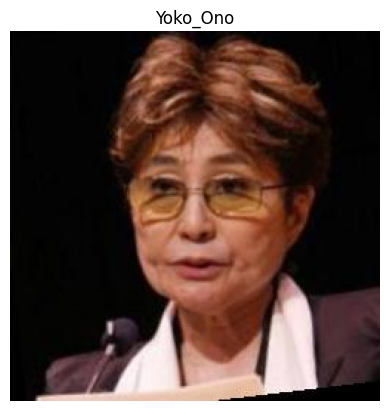

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

person = random.choice(os.listdir(train_dir))
img = random.choice(os.listdir(os.path.join(train_dir, person)))

img_path = os.path.join(train_dir, person, img)

plt.imshow(Image.open(img_path))
plt.title(person)
plt.axis("off")
plt.show()

In [ ]:
for person in os.listdir(train_dir):
    person_path = os.path.join(train_dir, person)
    if os.path.isdir(person_path):
        print(person, "->", len(os.listdir(person_path)))

Heidi_Fleiss -> 3
Claudia_Pechstein -> 4
Salma_Hayek -> 10
Martina_McBride -> 4
JK_Rowling -> 4
Amer_al-Saadi -> 3
Paul_ONeill -> 7
David_Wells -> 5
Sophia_Loren -> 5
Rita_Wilson -> 3
Jesse_Jackson -> 7
Joseph_Biden -> 4
Holly_Hunter -> 5
Geoff_Hoon -> 5
George_Lopez -> 4
Elizabeth_Hurley -> 4
Hipolito_Mejia -> 3
Costas_Simitis -> 4
Win_Aung -> 3
Justin_Leonard -> 3
Queen_Elizabeth_II -> 10
Jennifer_Aniston -> 16
Jacques_Rogge -> 8
Bob_Huggins -> 3
Andy_Roddick -> 12
Osama_bin_Laden -> 3
John_Paul_II -> 8
Zoran_Djindjic -> 3
Tom_Hanks -> 8
Diana_Krall -> 4
Walter_Mondale -> 8
Dick_Cheney -> 11
Zhang_Ziyi -> 3
Padraig_Harrington -> 3
Naoto_Kan -> 3
Robert_Mueller -> 4
Paul_Burrell -> 8
Laura_Linney -> 3
Adam_Sandler -> 3
Giuseppe_Gibilisco -> 3
Martha_Stewart -> 4
Spencer_Abraham -> 13
Antonio_Palocci -> 6
Benazir_Bhutto -> 4
Vaclav_Havel -> 7
Fidel_Castro -> 14
Sarah_Jessica_Parker -> 4
Sandra_Bullock -> 3
Bill_McBride -> 8
Michael_Powell -> 4
Renee_Zellweger -> 13
Justin_Timberlake ->

In [ ]:
import os
import shutil
import random

source_dir = "/content/drive/MyDrive/Datasets 4/selected_faces"
output_dir = "/content/drive/MyDrive/Datasets 4/split_dataset"

train_dir = os.path.join(output_dir, "train")
test_dir = os.path.join(output_dir, "test")

split_ratio = 0.8
random.seed(42)

# remove old split_dataset first for a clean run
shutil.rmtree(output_dir, ignore_errors=True)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

train_count = 0
test_count = 0
people_processed = 0

for person_name in os.listdir(source_dir):
    person_path = os.path.join(source_dir, person_name)

    if not os.path.isdir(person_path):
        continue

    images = [
        f for f in os.listdir(person_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(images) < 2:
        continue

    random.shuffle(images)

    split_index = int(len(images) * split_ratio)
    if split_index == 0:
        split_index = 1
    if split_index == len(images):
        split_index = len(images) - 1

    train_images = images[:split_index]
    test_images = images[split_index:]

    person_train_dir = os.path.join(train_dir, person_name)
    person_test_dir = os.path.join(test_dir, person_name)

    os.makedirs(person_train_dir, exist_ok=True)
    os.makedirs(person_test_dir, exist_ok=True)

    for img in train_images:
        shutil.copy2(os.path.join(person_path, img), os.path.join(person_train_dir, img))
        train_count += 1

    for img in test_images:
        shutil.copy2(os.path.join(person_path, img), os.path.join(person_test_dir, img))
        test_count += 1

    people_processed += 1

print(f"People processed: {people_processed}")
print(f"Training images: {train_count}")
print(f"Testing images: {test_count}")
print(f"Dataset split saved in: {output_dir}")

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Datasets 4"))
print(os.path.exists("/content/drive/MyDrive/Datasets 4/split_dataset"))
print(os.listdir("/content/drive/MyDrive/Datasets 4/split_dataset"))

In [ ]:
!zip -r "/content/split_dataset.zip" "/content/drive/MyDrive/Datasets 4/split_dataset"

Streaming output truncated to the last 5000 lines.
  adding: content/drive/MyDrive/Datasets 4/split_dataset/train/John_Abizaid/John_Abizaid_0009.jpg (deflated 3%)
  adding: content/drive/MyDrive/Datasets 4/split_dataset/train/John_Abizaid/John_Abizaid_0001.jpg (deflated 1%)
  adding: content/drive/MyDrive/Datasets 4/split_dataset/train/John_Abizaid/John_Abizaid_0008.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/split_dataset/train/John_Abizaid/John_Abizaid_0002.jpg (deflated 1%)
  adding: content/drive/MyDrive/Datasets 4/split_dataset/train/John_Abizaid/John_Abizaid_0006.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/split_dataset/train/Ahmed_Chalabi/ (stored 0%)
  adding: content/drive/MyDrive/Datasets 4/split_dataset/train/Ahmed_Chalabi/Ahmed_Chalabi_0003.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/split_dataset/train/Ahmed_Chalabi/Ahmed_Chalabi_0004.jpg (deflated 2%)
  adding: content/drive/MyDrive/Datasets 4/split_dataset/train/Ahmed_Ch

In [ ]:
from google.colab import files
files.download("/content/split_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>